In [1]:
!pip install camel-tools
!camel_data light
!pip install camel-tools --upgrade -q
!camel_data -l
!camel_data -i disambig-mle-calima-msa-r13


!pip install openpyxl

!pip install arabic-reshaper python-bidi


Usage:
    camel_data (-i | --install) [-f | --force] <PACKAGE>
    camel_data (-p | --post-install) <PACKAGE> <ARGS>...
    camel_data (-l | --list)
    camel_data (-u | --update)
    camel_data (-v | --version)
    camel_data (-h | --help)
Package Name                      Size  License     Description
----------------------------  --------  ----------  -------------------------------------------------------------------------------------------------------------------------
all                                                 All available CAMeL Tools packages
defaults                                            Default datasets for all CAMeL Tools components
dialectid-all                                       All available dialect identification models
dialectid-model26             371.2 MB  MIT         Dialect identification model trained to differentiating between 25 Arabic city dialects as well as Modern Standard Arabic
dialectid-model6              153.0 MB  MIT         Dialect ide

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
import re
import pandas as pd

In [4]:
df = pd.read_csv("All_Articles_Combined(Sheet1).csv", encoding="utf-8")
df.head()


,title,keywords,abstract,domain,reviewer,reviewer_profession,Impact_Factor
0,أهمية الخرسانة عالية الأداء في العصر الرقمي,الخرسانة عالية الأداء، تصميم، بناء، هندسة، معماري,تتناول هذه الورقة البحثية موضوع الخرسانة عالية...,هندسة,حمد فؤاد المهنا,باحث أساسي الهيئة العامة للتعليم التطبيقي وال...,1.922
1,البناء الأخضر والتقنيات الحديثة وتحديات العصر ...,البناء الأخضر والتقنيات الحديثة، تصميم، بناء، ...,في ظل التطورات الحديثة، أصبح البناء الأخضر وال...,هندسة,حمد فؤاد المهنا,باحث أساسي الهيئة العامة للتعليم التطبيقي وال...,1.922
2,فاعلية أنظمة الإضاءة الطبيعية في تحسين الأداء,أنظمة الإضاءة الطبيعية، تصميم، بناء، هندسة، مع...,يعتبر أنظمة الإضاءة الطبيعية من القضايا الأساس...,هندسة,أنور عبدهللا الغانم,عضو هيئة تدريب - الهيئة العامة للتعليم التطبيق...,1.922
3,تأثير تصميم المطارات الحديثة على المجتمع,تصميم المطارات الحديثة، تصميم، بناء، هندسة، مع...,تشكل تصميم المطارات الحديثة من القضايا الأساسي...,هندسة,منى حمد عبدالله آل عشيوان,NaN,1.922
4,تأثير التصميم المعماري للمستشفيات على المجتمع,التصميم المعماري للمستشفيات، تصميم، بناء، هندس...,تسعى هذه الدراسة إلى التصميم المعماري للمستشفي...,هندسة,إمام خلف الله علي حسين,مدرب متخصص المعهد الصناعي,1.922


In [5]:
df.columns = df.columns.str.strip()

# Prétraitement structurel

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                400 non-null    object 
 1   keywords             400 non-null    object 
 2   abstract             400 non-null    object 
 3   domain               400 non-null    object 
 4   reviewer             400 non-null    object 
 5   reviewer_profession  375 non-null    object 
 6   Impact_Factor        400 non-null    float64
dtypes: float64(1), object(6)
memory usage: 22.0+ KB


In [7]:
df.isnull().sum()

,0
title,0
keywords,0
abstract,0
domain,0
reviewer,0
reviewer_profession,25
Impact_Factor,0


In [8]:
print(df.columns)


Index(['title', 'keywords', 'abstract', 'domain', 'reviewer',
       'reviewer_profession', 'Impact_Factor'],
      dtype='object')


In [9]:
counts = df.groupby('reviewer').size().reset_index(name='n_rows')
counts = counts.sort_values('n_rows', ascending=False).reset_index(drop=True)
print(f"Nombre total de reviewers : {counts.shape[0]}\n")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', None)

print(counts)

Nombre total de reviewers : 70

                             reviewer  n_rows
0                عبدالله سعود السميري      10
1                     شريف كمال دسوقي      10
2                 أنور عبدهللا الغانم      10
3           منى حمد عبدالله آل عشيوان      10
4                           سوسن محمد      10
5              عبد هللا بن يوسف الجبر      10
6              خالد صالح الدين الخياط      10
7                  زينة مروان الشربتي      10
8                   سعداء عوض المطرفي      10
9                     علي محمد القاسم      10
10   غادة بنت خليفة بن حرقوص الراشدية       5
11                   فالح عواد الحربي       5
12    فاطمة عبدهللا علي عمران الكواري       5
13            غدير حسين إبراهيم التوم       5
14           . إيمان إبراهيم العمريطي       5
15              علي عبدالعزيز السيافي       5
16         عبد العزيزمحمد عمر البلوشي       5
17               عبد الرزاق عمر جاجان       5
18                 عبد الرحيم ال راجي       5
19              فالح محمد فياض العديم       5
20

In [10]:
counts = df.groupby('domain').size().reset_index(name='n_rows')
counts = counts.sort_values('n_rows', ascending=False).reset_index(drop=True)
print(f"Nombre total de domaines : {counts.shape[0]}\n")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', None)

print(counts)

Nombre total de domaines : 4

     domain  n_rows
0  إجتماعية     100
1        طب     100
2     قانون     100
3     هندسة     100


In [11]:
df = df.drop_duplicates(subset=['title'])

on va supprimer les articles ou on a un reviewer ou son profession est nan ou vide

In [12]:
df = df.dropna(subset=['reviewer_profession'])
df = df[df['reviewer_profession'].astype(str).str.strip() != '']

In [13]:
df = df.dropna(subset=['reviewer'])
df = df[df['reviewer'].astype(str).str.strip() != '']

Pour les valeurs manquants de Impact_Factor on va les remplacer par la moyenne des Impact_Factor de ce meme Reviewer

In [14]:
df['Impact_Factor'] = pd.to_numeric(df['Impact_Factor'], errors='coerce')
mean_per_reviewer = df.groupby('reviewer')['Impact_Factor'].transform('mean')
df['Impact_Factor'] = df['Impact_Factor'].fillna(mean_per_reviewer)

si abstarct manquant alors il va prendre keywords avec titre si une des titre et keyword n existe pas alors on va supprimer le ligne   

si titre est manquant il va prendre les keywords et si keywords aussi son monquant dans cette ligne alors il va etre supprimer   

si keywords sont manquant alors on va supprimer le ligne


In [15]:
df['abstract'] = df['abstract'].replace('', pd.NA)
df['title'] = df['title'].replace('', pd.NA)
df['keywords'] = df['keywords'].replace('', pd.NA)

Traitement des abstract:

In [16]:
mask_abstract_missing = df['abstract'].isna()

# Lignes où abstract manquant mais keywords et title présents on va remplir
df.loc[
    mask_abstract_missing & df['keywords'].notna() & df['title'].notna(),
    'abstract'
] = (df['keywords'] + ' ' + df['title']).str.strip()

# Lignes où abstract manquant ET (keywords ou title) manquant on va supprimer
df = df[~(mask_abstract_missing & (df['keywords'].isna() | df['title'].isna()))]

Traitement des titres:

In [17]:
mask_title_missing = df['title'].isna()
df.loc[mask_title_missing & df['keywords'].notna(), 'title'] = df['keywords']
df = df[~(mask_title_missing & df['keywords'].isna())]

Traitement des key words:

In [18]:
df = df[df['keywords'].notna()]

Pour domaine manquants on va donner le domaine majoritaire du reviewer

In [19]:
df['domain'] = df['domain'].replace('', pd.NA)

majority_domain = df.groupby('reviewer')['domain'] \
                    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)

df['domain'] = df.apply(
    lambda row: majority_domain[row['reviewer']] if pd.isna(row['domain']) else row['domain'],
    axis=1
)


reinitalisation des index:

In [20]:
df = df.reset_index(drop=True)

In [21]:
df.isnull().sum()

,0
title,0
keywords,0
abstract,0
domain,0
reviewer,0
reviewer_profession,0
Impact_Factor,0


In [22]:
counts = df.groupby('reviewer').size().reset_index(name='n_rows')
counts = counts.sort_values('n_rows', ascending=False).reset_index(drop=True)
print(f"Nombre total de reviewers : {counts.shape[0]}\n")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', None)

print(counts)

Nombre total de reviewers : 66

                             reviewer  n_rows
0                           سوسن محمد      10
1              خالد صالح الدين الخياط      10
2                     علي محمد القاسم      10
3              عبد هللا بن يوسف الجبر       9
4                  زينة مروان الشربتي       9
5                 أنور عبدهللا الغانم       9
6                     شريف كمال دسوقي       9
7                عبدالله سعود السميري       9
8                   سعداء عوض المطرفي       6
9       شروق تيسير عبد الغني ابو دبوس       5
10                أبرار ناصر علي حمدي       5
11                 عائشة محمد الظاهري       5
12           عاصم محمد عبد الحميد علي       5
13             عبد الرحمن محمد البخيت       5
14               عبد الرزاق عمر جاجان       5
15           . إيمان إبراهيم العمريطي       5
16               سلطان فيحان أبا العا       5
17   غادة بنت خليفة بن حرقوص الراشدية       5
18            غدير حسين إبراهيم التوم       5
19    فاطمة عبدهللا علي عمران الكواري       5
20

In [23]:
counts = df.groupby('domain').size().reset_index(name='n_rows')
counts = counts.sort_values('n_rows', ascending=False).reset_index(drop=True)
print(f"Nombre total de domaines : {counts.shape[0]}\n")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', None)

print(counts)

Nombre total de domaines : 4

     domain  n_rows
0        طب      89
1     قانون      85
2     هندسة      84
3  إجتماعية      81


In [24]:
df.to_excel('Data_nettoye.xlsx', index=False, engine='openpyxl')

# Prétraitement linguistique

In [25]:
def clean_text_ar(text,v):
    # Normalize alef
    text = re.sub(r'[أإآا]', 'ا', text)
    text = re.sub(r'پ', 'ب', text)
    text = re.sub(r'ڤ', 'ف', text)
    text = re.sub(r'ڨ', 'ق', text)
    text = re.sub(r'گ', 'ك', text)
    text = re.sub(r'چ', 'ش', text)
    text = re.sub(r'ژ', 'ز', text)
    # Remove diacritiques arabes
    #arabic_diacritics = re.compile(r'[\u0617-\u061A\u064B-\u0652\u0653-\u065F]')
    arabic_diacritics = re.compile(r'[\u0617-\u061A\u064B-\u0652\u0653-\u065F\u0670]')
    text = re.sub(arabic_diacritics, '', text)
    # Remove Arabic tatweel (ـ)
    text = re.sub(r'ـ', '', text)
    # Remove digits (Latin + Arabic)
    text = re.sub(r'[\d\u0660-\u0669]+', '', text)
    if v==1:
      # Remove punctuation sans les vergules
      text = re.sub(r'[؛؟.!"#$%&\'()*+\-/:;<=>?@[\]^_`{|}~«»]', '', text) #sans enlever les ,
      # Remove non-Arabic words sans les vergules
      text = re.sub(r'[^\u0600-\u06FF\s,]', '', text)
    else:
      # Remove punctuation
      text = re.sub(r'[،؛؟.!"#$%&\'()*+,-/:;<=>?@[\]^_`{|}~«»]', '', text)
      # Remove non-Arabic words
      text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    # Remove duplicate spaces
    text = re.sub(r'\s+', ' ', text)
    return text

In [26]:
from camel_tools.disambig.mle import MLEDisambiguator
from camel_tools.tokenizers.word import simple_word_tokenize

In [27]:
disambig = MLEDisambiguator.pretrained()

def clean_token(token):
    token = token.replace('_', '')
    arabic_diacritics = re.compile(r'[\u0617-\u061A\u064B-\u0652\u0653-\u065F\u0670]')
    token = re.sub(arabic_diacritics, '', token)
    return token

def tokenize_with_segmentation(text, keep_affixes=False):
    affixes = {'و', 'ف', 'ب', 'ك', 'ل', 'ال', 'لل', 'س','ه','ها','هم','هما','هن','ك','كم','كما','كن','ي','نا','ني',}

    words = simple_word_tokenize(text)
    disambiguated = disambig.disambiguate(words)
    all_tokens = []

    for word_analysis in disambiguated:
        word = word_analysis.word
        best_analysis = word_analysis.analyses[0]

        lemma = best_analysis.analysis.get('lex')
        if lemma in [None, 'NOAN']:
            lemma = word

        # Cas 1: Mot non reconnu (NOAN)
        if lemma == 'NOAN':
            #cleaned = clean_token(word)
            cleaned = clean_text_ar(word,0)
            if cleaned:
                all_tokens.append(cleaned)

        # Cas 2: Mot reconnu
        else:
            segments = best_analysis.analysis.get('d3tok', word)
            if not segments or 'NOAN' in segments:
                #cleaned = clean_token(word)
                cleaned = clean_text_ar(word,0)
                if cleaned:
                    all_tokens.append(cleaned)
                continue
            # Si segmentation possible
            if '+' in segments:
                tokens = segments.split('+')
                #tokens = [clean_token(t) for t in tokens if t]
                tokens = [clean_text_ar(t,0) for t in tokens if t]
                if not keep_affixes:
                    tokens = [t for t in tokens if t not in affixes and len(t) > 1]
                all_tokens.extend(tokens)

            # Sinon, garder le mot tel quel
            else:
                #cleaned = clean_token(word)
                cleaned = clean_text_ar(word,0)
                if cleaned:
                    all_tokens.append(cleaned)

    # Filtrer les tokens vides
    all_tokens = [t for t in all_tokens if t]
    return all_tokens

In [28]:
def lemmatize_tokens(tokens):
    disambiguated = disambig.disambiguate(tokens)
    lemmas = []
    for word_analysis in disambiguated:
        word = word_analysis.word
        analyses = word_analysis.analyses

        if analyses:
            best_analysis = analyses[0]
            lemma = best_analysis.analysis.get('lex')
            if lemma in [None, 'NOAN']:
                lemma = word
            #cleaned = clean_token(lemma)
            cleaned = clean_text_ar(lemma,0)
            if cleaned and cleaned != 'NOAN':
                lemmas.append(cleaned)
        else:
            #cleaned = clean_token(word)
            cleaned = clean_text_ar(word,0)
            if cleaned:
                lemmas.append(cleaned)

    return lemmas

**Keywords**

Separteur de keywords va devenir , pour tous les colonnes

In [29]:
df['keywords'] = df['keywords'].str.replace(r'[;–\-|،]', ',', regex=True) #ici n ne doit pas oublier la vergule arabe ،
df['keywords'] = df['keywords'].str.replace(r'\s*,\s*', ',', regex=True)
df['keywords'] = df['keywords'].str.strip()

In [30]:
df['keywords'] = df['keywords'].astype(str).apply(lambda x: clean_text_ar(x, v=1))

tokenisation des keywords

In [31]:
df['keywords'] = df['keywords'].apply(lambda x: [kw.strip() for kw in x.split(',') if kw.strip() != ''])

In [32]:
df.head()

,title,keywords,abstract,domain,reviewer,reviewer_profession,Impact_Factor
0,أهمية الخرسانة عالية الأداء في العصر الرقمي,"[الخرسانة عالية الاداء, تصميم, بناء, هندسة, معماري]",تتناول هذه الورقة البحثية موضوع الخرسانة عالية الأداء كأحد القضايا المعاصرة التي تستحق الدراسة والتحليل. تم استخدام المنهج الوصفي والتحليلي لجمع البيانات وتحليلها. خلصت الدراسة إلى عدة نتائج مهمة تتعلق بتحسين الوضع الحالي. توصي الدراسة بضرورة إجراء المزيد من البحوث في هذا المجال.,هندسة,حمد فؤاد المهنا,باحث أساسي الهيئة العامة للتعليم التطبيقي والتدريب,1.922
1,البناء الأخضر والتقنيات الحديثة وتحديات العصر الحديث,"[البناء الاخضر والتقنيات الحديثة, تصميم, بناء, هندسة, معماري]",في ظل التطورات الحديثة، أصبح البناء الأخضر والتقنيات الحديثة من المواضيع التي تحظى باهتمام كبير. تهدف هذه الدراسة إلى استكشاف الجوانب المختلفة لهذا الموضوع وتقديم رؤية شاملة. اعتمد البحث على تحليل البيانات المتاحة والدراسات السابقة. توصلت الدراسة إلى توصيات عملية يمكن تطبيقها في الميدان. توصي الدراسة بضرورة تطبيق النتائج في الميدان العملي.,هندسة,حمد فؤاد المهنا,باحث أساسي الهيئة العامة للتعليم التطبيقي والتدريب,1.922
2,فاعلية أنظمة الإضاءة الطبيعية في تحسين الأداء,"[انظمة الاضاءة الطبيعية, تصميم, بناء, هندسة, معماري]",يعتبر أنظمة الإضاءة الطبيعية من القضايا الأساسية التي تؤثر على مختلف جوانب الحياة. تسعى هذه الدراسة إلى فهم أبعاد هذه القضية وتحديد العوامل المؤثرة فيها. استخدم الباحث المنهج الوصفي التحليلي في جمع وتحليل البيانات. أظهرت النتائج وجود علاقات مهمة بين المتغيرات المدروسة. توصي الدراسة بضرورة تعزيز التعاون بين الجهات المعنية.,هندسة,أنور عبدهللا الغانم,عضو هيئة تدريب - الهيئة العامة للتعليم التطبيقي والتدريب,1.922
3,تأثير التصميم المعماري للمستشفيات على المجتمع,"[التصميم المعماري للمستشفيات, تصميم, بناء, هندسة, معماري]",تسعى هذه الدراسة إلى التصميم المعماري للمستشفيات من خلال تحليل الوضع الراهن وتحديد التحديات. اعتمدت الدراسة على المنهج التجريبي والتحليلي. كشفت النتائج عن وجود تأثيرات إيجابية على الجوانب المختلفة. توصي الدراسة بضرورة تطوير البرامج التدريبية.,هندسة,إمام خلف الله علي حسين,مدرب متخصص المعهد الصناعي,1.922
4,التصميم الزلزالي للمنشآت: دراسة ميدانية,"[التصميم الزلزالي للمنشات, تصميم, بناء, هندسة, معماري]",تتناول هذه الورقة البحثية موضوع التصميم الزلزالي للمنشآت كأحد القضايا المعاصرة التي تستحق الدراسة والتحليل. تم استخدام المنهج الوصفي والتحليلي لجمع البيانات وتحليلها. خلصت الدراسة إلى عدة نتائج مهمة تتعلق بتحسين الوضع الحالي. توصي الدراسة بضرورة إجراء المزيد من البحوث في هذا المجال.,هندسة,أبرار ناصر علي حمدي,طالبة ماجستير، كلية العمارة والتخطيط،,1.922


**titre et abstract**

In [33]:
df['title'] = df['title'].astype(str).apply(lambda x: clean_text_ar(x, v=0))
df['abstract'] = df['abstract'].astype(str).apply(lambda x: clean_text_ar(x, v=0))
df['reviewer_profession'] = df['reviewer_profession'].astype(str).apply(lambda x: clean_text_ar(x, v=0))
df['domain'] = df['domain'].astype(str).apply(lambda x: clean_text_ar(x, v=0))

In [34]:
df.head()

,title,keywords,abstract,domain,reviewer,reviewer_profession,Impact_Factor
0,اهمية الخرسانة عالية الاداء في العصر الرقمي,"[الخرسانة عالية الاداء, تصميم, بناء, هندسة, معماري]",تتناول هذه الورقة البحثية موضوع الخرسانة عالية الاداء كاحد القضايا المعاصرة التي تستحق الدراسة والتحليل تم استخدام المنهج الوصفي والتحليلي لجمع البيانات وتحليلها خلصت الدراسة الى عدة نتائج مهمة تتعلق بتحسين الوضع الحالي توصي الدراسة بضرورة اجراء المزيد من البحوث في هذا المجال,هندسة,حمد فؤاد المهنا,باحث اساسي الهيئة العامة للتعليم التطبيقي والتدريب,1.922
1,البناء الاخضر والتقنيات الحديثة وتحديات العصر الحديث,"[البناء الاخضر والتقنيات الحديثة, تصميم, بناء, هندسة, معماري]",في ظل التطورات الحديثة اصبح البناء الاخضر والتقنيات الحديثة من المواضيع التي تحظى باهتمام كبير تهدف هذه الدراسة الى استكشاف الجوانب المختلفة لهذا الموضوع وتقديم رؤية شاملة اعتمد البحث على تحليل البيانات المتاحة والدراسات السابقة توصلت الدراسة الى توصيات عملية يمكن تطبيقها في الميدان توصي الدراسة بضرورة تطبيق النتائج في الميدان العملي,هندسة,حمد فؤاد المهنا,باحث اساسي الهيئة العامة للتعليم التطبيقي والتدريب,1.922
2,فاعلية انظمة الاضاءة الطبيعية في تحسين الاداء,"[انظمة الاضاءة الطبيعية, تصميم, بناء, هندسة, معماري]",يعتبر انظمة الاضاءة الطبيعية من القضايا الاساسية التي تؤثر على مختلف جوانب الحياة تسعى هذه الدراسة الى فهم ابعاد هذه القضية وتحديد العوامل المؤثرة فيها استخدم الباحث المنهج الوصفي التحليلي في جمع وتحليل البيانات اظهرت النتائج وجود علاقات مهمة بين المتغيرات المدروسة توصي الدراسة بضرورة تعزيز التعاون بين الجهات المعنية,هندسة,أنور عبدهللا الغانم,عضو هيئة تدريب الهيئة العامة للتعليم التطبيقي والتدريب,1.922
3,تاثير التصميم المعماري للمستشفيات على المجتمع,"[التصميم المعماري للمستشفيات, تصميم, بناء, هندسة, معماري]",تسعى هذه الدراسة الى التصميم المعماري للمستشفيات من خلال تحليل الوضع الراهن وتحديد التحديات اعتمدت الدراسة على المنهج التجريبي والتحليلي كشفت النتائج عن وجود تاثيرات ايجابية على الجوانب المختلفة توصي الدراسة بضرورة تطوير البرامج التدريبية,هندسة,إمام خلف الله علي حسين,مدرب متخصص المعهد الصناعي,1.922
4,التصميم الزلزالي للمنشات دراسة ميدانية,"[التصميم الزلزالي للمنشات, تصميم, بناء, هندسة, معماري]",تتناول هذه الورقة البحثية موضوع التصميم الزلزالي للمنشات كاحد القضايا المعاصرة التي تستحق الدراسة والتحليل تم استخدام المنهج الوصفي والتحليلي لجمع البيانات وتحليلها خلصت الدراسة الى عدة نتائج مهمة تتعلق بتحسين الوضع الحالي توصي الدراسة بضرورة اجراء المزيد من البحوث في هذا المجال,هندسة,أبرار ناصر علي حمدي,طالبة ماجستير كلية العمارة والتخطيط,1.922


In [35]:
#from camel_tools.tokenizers.word import simple_word_tokenize

df['title'] = df['title'].apply(tokenize_with_segmentation)
df['abstract'] = df['abstract'].apply(tokenize_with_segmentation)
df['domain'] = df['domain'].apply(tokenize_with_segmentation)
df['reviewer_profession'] = df['reviewer_profession'].apply(tokenize_with_segmentation)

In [36]:
df['title'] = df['title'].apply(lemmatize_tokens)
df['abstract'] = df['abstract'].apply(lemmatize_tokens)
df['domain'] = df['domain'].apply(lemmatize_tokens)
df['reviewer_profession'] = df['reviewer_profession'].apply(lemmatize_tokens)

In [37]:
df.head()

,title,keywords,abstract,domain,reviewer,reviewer_profession,Impact_Factor
0,"[اهمية, اخرس, عالي, اداء, في, عصر, رقمي]","[الخرسانة عالية الاداء, تصميم, بناء, هندسة, معماري]","[تناول, هذا, ورق, بحثي, موضوع, اخرس, عالي, اداء, احد, قضية, معاصر, الذي, ٱستحق, دراسة, تحليل, تم, ٱستخدام, منهج, صف, تحليلي, جمع, بيان, تحليل, خلص, دراسة, الى, عدة, نتيجة, مهم, تعلق, تحسين, وضع, حالي, اوصى, دراسة, ضرورة, اجراء, مزيد, من, بحث, في, هذا, مجال]",[هندسة],حمد فؤاد المهنا,"[باحث, اساسي, هيئة, عام, تعليم, تطبيق, تدريب]",1.922
1,"[بناء, اخضر, تقنية, حديث, تحدي, عصر, حديث]","[البناء الاخضر والتقنيات الحديثة, تصميم, بناء, هندسة, معماري]","[في, ظل, تطورات, حديث, اصبح, بناء, اخضر, تقنية, حديث, من, موضوع, الذي, حظي, ٱهتمام, كبير, هدف, هذا, دراسة, الى, ٱستكشاف, جانب, مختلف, هذا, موضوع, تقديم, رؤية, شامل, ٱعتمد, بحث, على, تحليل, بيان, متاح, دراسة, سابق, توصل, دراسة, الى, توصية, عملية, امكن, تطبيق, في, ميدان, اوصى, دراسة, ضرورة, تطبيق, نتيجة, في, ميدان, عملي]",[هندسة],حمد فؤاد المهنا,"[باحث, اساسي, هيئة, عام, تعليم, تطبيق, تدريب]",1.922
2,"[فاعلية, نظام, اضاء, طبيعي, في, تحسين, اداء]","[انظمة الاضاءة الطبيعية, تصميم, بناء, هندسة, معماري]","[ٱعتبر, نظام, اضاء, طبيعي, من, قضية, اساسي, الذي, اثر, على, مختلف, جانب, حياة, سعى, هذا, دراسة, الى, ابعاد, هذا, قضية, تحديد, عامل, مؤثر, في, ٱستخدم, باحث, منهج, صف, تحليلي, في, جمع, تحليل, بيان, اظهر, نتيجة, وجود, علاقة, مهم, بين, متغير, مدروس, اوصى, دراسة, ضرورة, تعزيز, تعاون, بين, جهة, معني]",[هندسة],أنور عبدهللا الغانم,"[عضو, هيئة, تدريب, هيئة, عام, تعليم, تطبيق, تدريب]",1.922
3,"[تاثير, تصميم, معماري, مستشفى, على, مجتمع]","[التصميم المعماري للمستشفيات, تصميم, بناء, هندسة, معماري]","[سعى, هذا, دراسة, الى, تصميم, معماري, مستشفى, من, خلال, تحليل, وضع, راهن, تحديد, تحدي, ٱعتمد, دراسة, على, منهج, تجريبي, تحليلي, كشف, نتيجة, عن, وجود, تاثير, ايجابي, على, جانب, مختلف, اوصى, دراسة, ضرورة, تطوير, برنامج, تدريبي]",[هندسة],إمام خلف الله علي حسين,"[مدرب, متخصص, معهد, صناعي]",1.922
4,"[تصميم, زلزال, منشاة, دراسة, ميداني]","[التصميم الزلزالي للمنشات, تصميم, بناء, هندسة, معماري]","[تناول, هذا, ورق, بحثي, موضوع, تصميم, زلزال, منشاة, احد, قضية, معاصر, الذي, ٱستحق, دراسة, تحليل, تم, ٱستخدام, منهج, صف, تحليلي, جمع, بيان, تحليل, خلص, دراسة, الى, عدة, نتيجة, مهم, تعلق, تحسين, وضع, حالي, اوصى, دراسة, ضرورة, اجراء, مزيد, من, بحث, في, هذا, مجال]",[هندسة],أبرار ناصر علي حمدي,"[طالب, ماجستير, كلية, عمارة, تخطيط]",1.922


In [38]:
df.to_excel('testCleaning et tokenisation.xlsx', index=False, engine='openpyxl')

On va supprimer les STOP WORDS

In [39]:
with open("arabic_stopwords.txt", encoding="utf-8") as f:
    arabic_stopwords = f.read().splitlines()
def remove_stopwords(tokens):
    return [word for word in tokens if word not in arabic_stopwords]

In [40]:
df['title'] = df['title'].apply(remove_stopwords)
df['abstract'] = df['abstract'].apply(remove_stopwords)
df['domain'] = df['domain'].apply(remove_stopwords)
df['reviewer_profession'] = df['reviewer_profession'].apply(remove_stopwords)

In [41]:
df.head()

,title,keywords,abstract,domain,reviewer,reviewer_profession,Impact_Factor
0,"[اهمية, اخرس, عالي, اداء, عصر, رقمي]","[الخرسانة عالية الاداء, تصميم, بناء, هندسة, معماري]","[تناول, ورق, بحثي, موضوع, اخرس, عالي, اداء, قضية, معاصر, ٱستحق, دراسة, تحليل, تم, ٱستخدام, منهج, صف, تحليلي, جمع, بيان, تحليل, خلص, دراسة, عدة, نتيجة, مهم, تعلق, تحسين, وضع, حالي, اوصى, دراسة, ضرورة, اجراء, مزيد, بحث, مجال]",[هندسة],حمد فؤاد المهنا,"[باحث, اساسي, هيئة, عام, تعليم, تطبيق, تدريب]",1.922
1,"[بناء, اخضر, تقنية, حديث, تحدي, عصر, حديث]","[البناء الاخضر والتقنيات الحديثة, تصميم, بناء, هندسة, معماري]","[ظل, تطورات, حديث, اصبح, بناء, اخضر, تقنية, حديث, موضوع, حظي, ٱهتمام, كبير, هدف, دراسة, ٱستكشاف, جانب, مختلف, موضوع, تقديم, رؤية, شامل, ٱعتمد, بحث, تحليل, بيان, متاح, دراسة, سابق, توصل, دراسة, توصية, عملية, امكن, تطبيق, ميدان, اوصى, دراسة, ضرورة, تطبيق, نتيجة, ميدان, عملي]",[هندسة],حمد فؤاد المهنا,"[باحث, اساسي, هيئة, عام, تعليم, تطبيق, تدريب]",1.922
2,"[فاعلية, نظام, اضاء, طبيعي, تحسين, اداء]","[انظمة الاضاءة الطبيعية, تصميم, بناء, هندسة, معماري]","[ٱعتبر, نظام, اضاء, طبيعي, قضية, اساسي, اثر, مختلف, جانب, حياة, سعى, دراسة, ابعاد, قضية, تحديد, عامل, مؤثر, ٱستخدم, باحث, منهج, صف, تحليلي, جمع, تحليل, بيان, اظهر, نتيجة, وجود, علاقة, مهم, متغير, مدروس, اوصى, دراسة, ضرورة, تعزيز, تعاون, جهة, معني]",[هندسة],أنور عبدهللا الغانم,"[عضو, هيئة, تدريب, هيئة, عام, تعليم, تطبيق, تدريب]",1.922
3,"[تاثير, تصميم, معماري, مستشفى, مجتمع]","[التصميم المعماري للمستشفيات, تصميم, بناء, هندسة, معماري]","[سعى, دراسة, تصميم, معماري, مستشفى, خلال, تحليل, وضع, راهن, تحديد, تحدي, ٱعتمد, دراسة, منهج, تجريبي, تحليلي, كشف, نتيجة, وجود, تاثير, ايجابي, جانب, مختلف, اوصى, دراسة, ضرورة, تطوير, برنامج, تدريبي]",[هندسة],إمام خلف الله علي حسين,"[مدرب, متخصص, معهد, صناعي]",1.922
4,"[تصميم, زلزال, منشاة, دراسة, ميداني]","[التصميم الزلزالي للمنشات, تصميم, بناء, هندسة, معماري]","[تناول, ورق, بحثي, موضوع, تصميم, زلزال, منشاة, قضية, معاصر, ٱستحق, دراسة, تحليل, تم, ٱستخدام, منهج, صف, تحليلي, جمع, بيان, تحليل, خلص, دراسة, عدة, نتيجة, مهم, تعلق, تحسين, وضع, حالي, اوصى, دراسة, ضرورة, اجراء, مزيد, بحث, مجال]",[هندسة],أبرار ناصر علي حمدي,"[طالب, ماجستير, كلية, عمارة, تخطيط]",1.922


In [42]:
!apt install fonts-dejavu -y
!wget -q https://github.com/google/fonts/raw/main/ofl/amiri/Amiri-Regular.ttf -O /usr/share/fonts/truetype/amiri.ttf
!pip install arabic-reshaper python-bidi

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-dejavu-core fonts-dejavu-extra
The following NEW packages will be installed:
  fonts-dejavu fonts-dejavu-core fonts-dejavu-extra
0 upgraded, 3 newly installed, 0 to remove and 1 not upgraded.
Need to get 3,085 kB of archives.
After this operation, 10.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2build1 [1,041 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-extra all 2.37-2build1 [2,041 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-dejavu all 2.37-2build1 [3,192 B]
Fetched 3,085 kB in 2s (1,918 kB/s)
Selecting previously unselected package fonts-dejavu-core.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-core_2.37-2build1_all.deb ...
Unpacki

In [43]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display

def generate_arabic_wordcloud(df, column_name, title="Word Cloud", font_path='/usr/share/fonts/truetype/amiri.ttf'):
    # Collect all tokens
    all_tokens = [
        tok for tokens in df[column_name]
        for tok in tokens if isinstance(tok, str) and tok.strip()
    ]

    # Count token frequencies
    freq = Counter(all_tokens)

    # Fix Arabic display
    freq_fixed = {}
    for token, count in freq.items():
        reshaped = arabic_reshaper.reshape(token)
        bidi_word = get_display(reshaped)
        visually_correct = bidi_word[::-1]  # reverse because WordCloud renders LTR
        freq_fixed[visually_correct] = count

    # Generate WordCloud
    wordcloud = WordCloud(
        font_path=font_path,
        width=1200,
        height=800,
        background_color='white',
        collocations=False
    ).generate_from_frequencies(freq_fixed)

    # Display
    plt.figure(figsize=(14, 9))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()


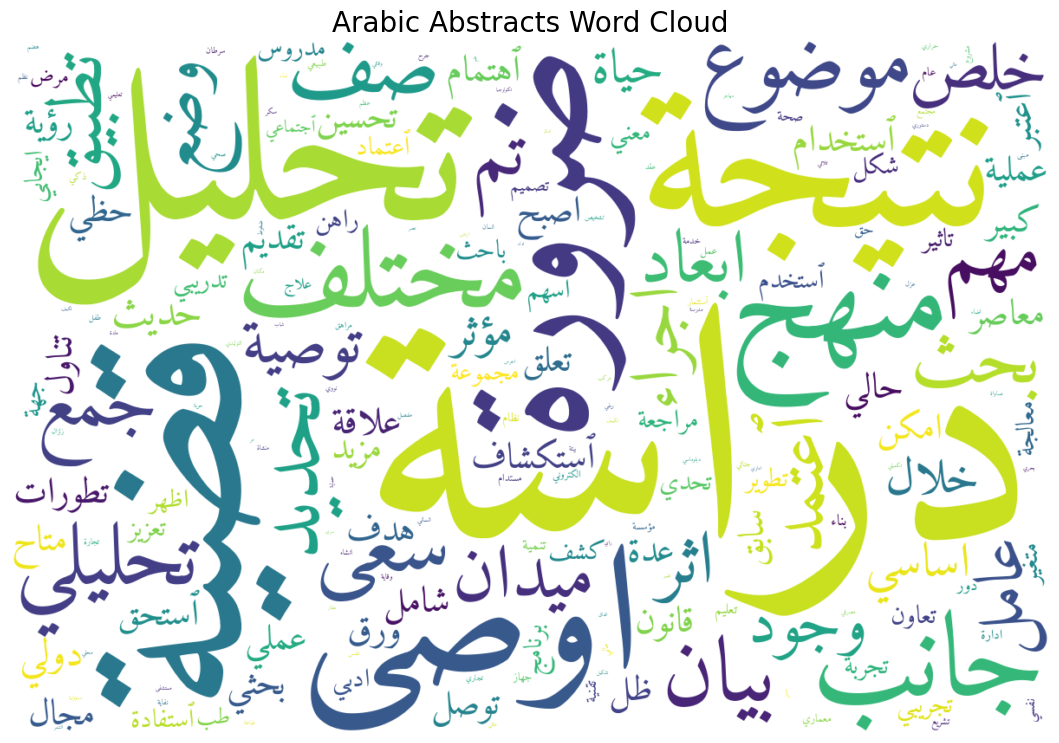

In [44]:
generate_arabic_wordcloud(df, 'abstract', title="Arabic Abstracts Word Cloud")

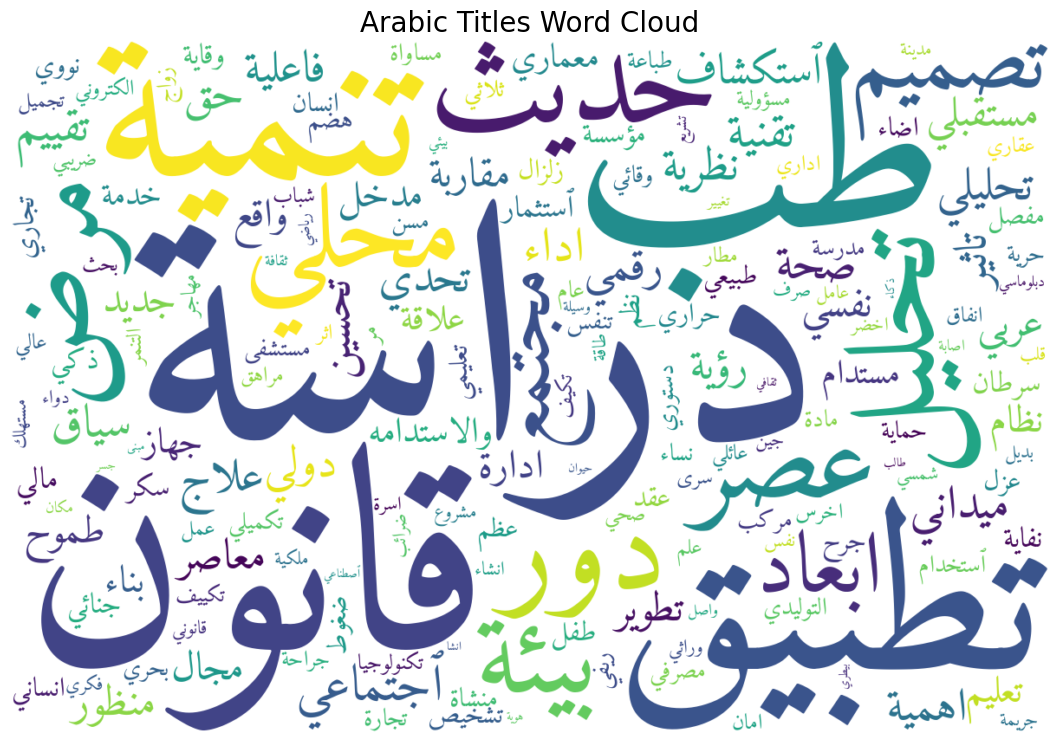

In [45]:
generate_arabic_wordcloud(df, 'title', title="Arabic Titles Word Cloud")

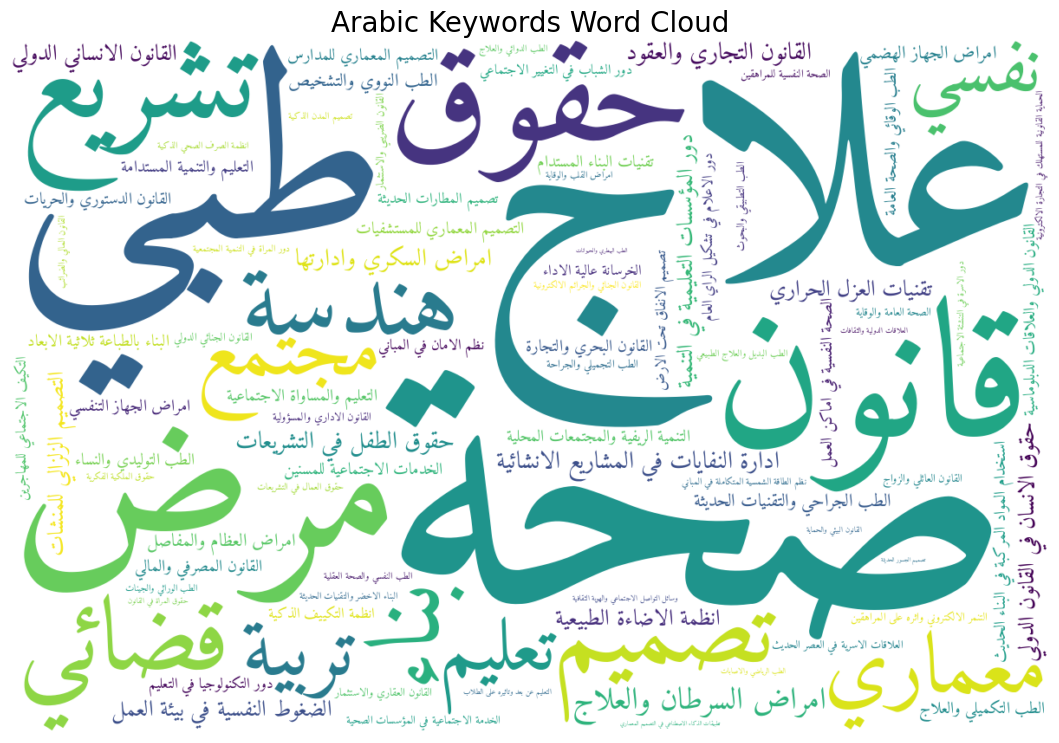

In [46]:
generate_arabic_wordcloud(df, 'keywords', title="Arabic Keywords Word Cloud")

In [47]:
import pandas as pd
from collections import Counter, defaultdict

def analyze_tokens(df, text_column='abstract', domain_column='domain', stop_threshold=0.5, balance_tolerance=0.2):
    total_counter = Counter()
    domain_counters = defaultdict(Counter)
    article_occurrences = defaultdict(set)

    for idx, row in df.iterrows():
        tokens = row[text_column]
        domain_tokens = row[domain_column]

        # Vérifier que tokens est une liste
        if not isinstance(tokens, list):
            continue

        if isinstance(domain_tokens, list):
            # Joindre les tokens pour former le nom complet du domaine
            domain_name = ' '.join(str(t) for t in domain_tokens if t)
        elif isinstance(domain_tokens, str):
            domain_name = domain_tokens
        else:
            domain_name = None

        # Si pas de domaine valide, skip
        if not domain_name or not domain_name.strip():
            continue

        domain_name = domain_name.strip()

        # Compter les tokens
        for tok in tokens:
            if isinstance(tok, str) and tok.strip():
                tok = tok.strip()
                total_counter[tok] += 1
                article_occurrences[tok].add(idx)

                # Compter pour ce domaine
                domain_counters[domain_name][tok] += 1

    all_domains = set()
    for domain_tokens in df[domain_column]:
        if isinstance(domain_tokens, list):
            domain_name = ' '.join(str(t) for t in domain_tokens if t).strip()
            if domain_name:
                all_domains.add(domain_name)
        elif isinstance(domain_tokens, str) and domain_tokens.strip():
            all_domains.add(domain_tokens.strip())

    all_domains = sorted(all_domains)
    n_domains = len(all_domains)

    print(f"Nombre de domaines trouvés: {n_domains}")
    print(f"Domaines:")
    for i, d in enumerate(all_domains, 1):
        print(f"   {i}. {d}")

    # Construire le DataFrame de résultats
    all_tokens = list(total_counter.keys())
    data = []

    for tok in all_tokens:
        row_data = {
            "Token": tok,
            "Total_Occurrences": total_counter[tok],
            "Articles_Count": len(article_occurrences[tok]),
        }

        # Compter dans chaque domaine
        domain_counts = [domain_counters[d][tok] for d in all_domains]

        # Ajouter colonnes par domaine
        for d, c in zip(all_domains, domain_counts):
            # Tronquer le nom si trop long
            col_name = d[:30] + "..." if len(d) > 30 else d
            row_data[f"Count_{col_name}"] = c

        # --- Logique Stop word ---
        domains_present = sum(1 for c in domain_counts if c > 0)
        domain_ratio = domains_present / max(1, n_domains)

        if domain_ratio >= stop_threshold:
            total = sum(domain_counts)
            if total > 0:
                proportions = [c / total for c in domain_counts]
                max_p, min_p = max(proportions), min(proportions)
                balanced = (max_p - min_p) <= balance_tolerance
                is_stopword = balanced
            else:
                is_stopword = False
        else:
            is_stopword = False

        row_data["Domain_Coverage"] = round(domain_ratio, 2)
        row_data["Stop_Word"] = is_stopword

        data.append(row_data)

    # Créer le DataFrame
    result_df = pd.DataFrame(data)
    result_df = result_df.sort_values(by="Total_Occurrences", ascending=False).reset_index(drop=True)
    result_df.index = [f"Token_{i+1}" for i in range(len(result_df))]

    return result_df

In [48]:
# Example: Analyze tokens in the "abstract" column grouped by "domain"
tokens_df = analyze_tokens(df, text_column='abstract', domain_column='domain')

# Show top 20 tokens
tokens_df.head(50)

Nombre de domaines trouvés: 4
Domaines:
   1. طب
   2. قانون
   3. هندسة
   4. ٱجتماعي


,Token,Total_Occurrences,Articles_Count,Count_طب,Count_قانون,Count_هندسة,Count_ٱجتماعي,Domain_Coverage,Stop_Word
Token_1,دراسة,1019,339,267,258,251,243,1.0,True
Token_2,تحليل,410,339,107,102,102,99,1.0,True
Token_3,قضية,399,203,105,104,102,88,1.0,True
Token_4,اوصى,339,339,89,85,84,81,1.0,True
Token_5,ضرورة,339,339,89,85,84,81,1.0,True
Token_6,نتيجة,339,339,89,85,84,81,1.0,True
Token_7,منهج,269,269,71,67,67,64,1.0,True
Token_8,مختلف,268,268,71,68,66,63,1.0,True
Token_9,جانب,268,268,71,68,66,63,1.0,True
Token_10,موضوع,211,141,54,53,52,52,1.0,True


In [49]:
abstract_stopwords_list = tokens_df.loc[tokens_df['Stop_Word'] == True, 'Token'].tolist()
len(abstract_stopwords_list)

93

In [50]:
def remove_stopwords_from_column(df, column_name, stopwords):
    df[column_name] = df[column_name].apply(
        lambda tokens: [tok for tok in tokens if tok not in stopwords] if isinstance(tokens, list) else tokens
    )
    return df

In [51]:
df = remove_stopwords_from_column(df, 'abstract', abstract_stopwords_list)
# Check how many abstracts still contain at least one stop word
remaining = df['abstract'].apply(
    lambda tokens: any(tok in abstract_stopwords_list for tok in tokens) if isinstance(tokens, list) else False
)

print(f"{len(df) - remaining.sum()} abstracts are fully cleaned.")
print(f"{remaining.sum()} abstracts still contain stop words.")


339 abstracts are fully cleaned.
0 abstracts still contain stop words.


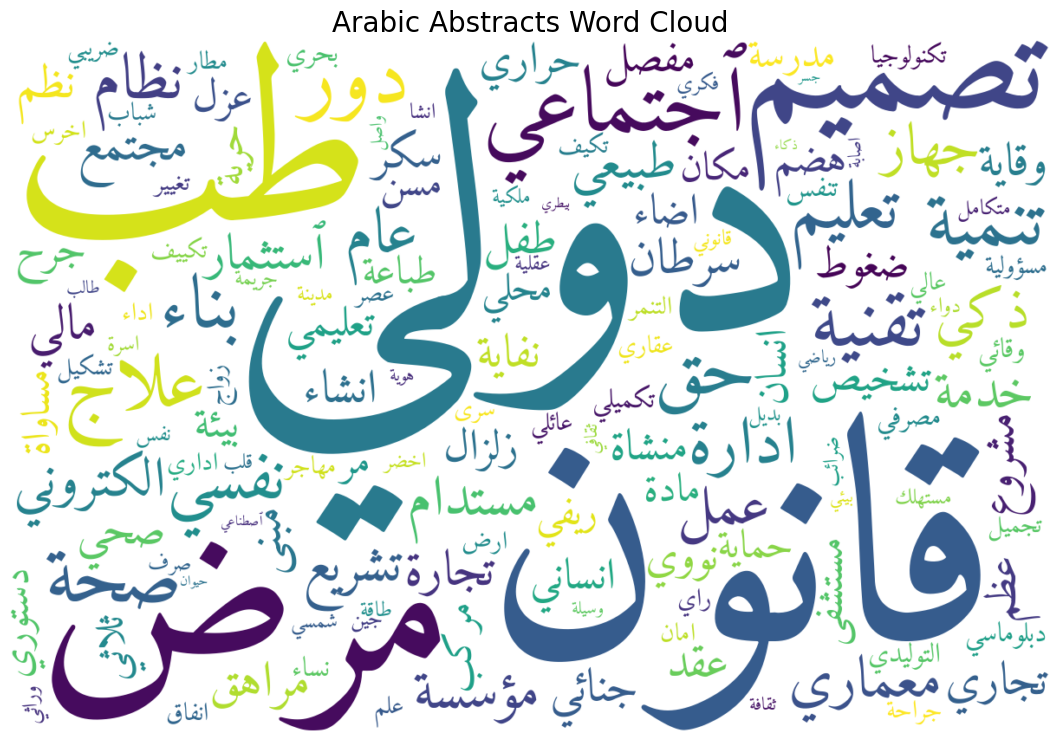

In [52]:
generate_arabic_wordcloud(df, 'abstract', title="Arabic Abstracts Word Cloud")

In [53]:
# Example: Analyze tokens in the "abstract" column grouped by "domain"
tokens_df = analyze_tokens(df, text_column='abstract', domain_column='domain')

# Show top 20 tokens
tokens_df.head(20)

Nombre de domaines trouvés: 4
Domaines:
   1. طب
   2. قانون
   3. هندسة
   4. ٱجتماعي


,Token,Total_Occurrences,Articles_Count,Count_طب,Count_قانون,Count_هندسة,Count_ٱجتماعي,Domain_Coverage,Stop_Word
Token_1,دولي,87,83,17,40,16,14,1.00,False
Token_2,قانون,69,69,0,69,0,0,0.25,False
Token_3,طب,50,50,50,0,0,0,0.25,False
Token_4,مرض,35,35,35,0,0,0,0.25,False
Token_5,تصميم,29,29,0,0,29,0,0.25,False
Token_6,ٱجتماعي,27,27,0,0,0,27,0.25,False
Token_7,دور,24,24,0,0,0,24,0.25,False
Token_8,حق,21,21,0,21,0,0,0.25,False
Token_9,صحة,21,21,12,0,0,9,0.50,False
Token_10,تقنية,20,20,6,0,14,0,0.50,False


In [54]:
df.head()

,title,keywords,abstract,domain,reviewer,reviewer_profession,Impact_Factor
0,"[اهمية, اخرس, عالي, اداء, عصر, رقمي]","[الخرسانة عالية الاداء, تصميم, بناء, هندسة, معماري]","[اخرس, عالي, اداء]",[هندسة],حمد فؤاد المهنا,"[باحث, اساسي, هيئة, عام, تعليم, تطبيق, تدريب]",1.922
1,"[بناء, اخضر, تقنية, حديث, تحدي, عصر, حديث]","[البناء الاخضر والتقنيات الحديثة, تصميم, بناء, هندسة, معماري]","[بناء, اخضر, تقنية]",[هندسة],حمد فؤاد المهنا,"[باحث, اساسي, هيئة, عام, تعليم, تطبيق, تدريب]",1.922
2,"[فاعلية, نظام, اضاء, طبيعي, تحسين, اداء]","[انظمة الاضاءة الطبيعية, تصميم, بناء, هندسة, معماري]","[نظام, اضاء, طبيعي]",[هندسة],أنور عبدهللا الغانم,"[عضو, هيئة, تدريب, هيئة, عام, تعليم, تطبيق, تدريب]",1.922
3,"[تاثير, تصميم, معماري, مستشفى, مجتمع]","[التصميم المعماري للمستشفيات, تصميم, بناء, هندسة, معماري]","[تصميم, معماري, مستشفى]",[هندسة],إمام خلف الله علي حسين,"[مدرب, متخصص, معهد, صناعي]",1.922
4,"[تصميم, زلزال, منشاة, دراسة, ميداني]","[التصميم الزلزالي للمنشات, تصميم, بناء, هندسة, معماري]","[تصميم, زلزال, منشاة]",[هندسة],أبرار ناصر علي حمدي,"[طالب, ماجستير, كلية, عمارة, تخطيط]",1.922


In [55]:
df.to_excel('Data_pretraite.xlsx', index=False, engine='openpyxl')

# Vectorisation TF-IDF

In [56]:
import numpy as np
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

On sépare les colonnes texte, colonnes numériques et la target (reviewer)

In [57]:
text_cols = ['title', 'abstract', 'keywords', 'reviewer_profession']
num_cols = ['Impact_Factor']
target = 'reviewer'

In [58]:
from collections import Counter

def remove_small_reviewers(df, target_col='reviewer', min_articles=3):
    class_counts = Counter(df[target_col])
    problematic_classes = [cls for cls, count in class_counts.items() if count < min_articles]

    print(f"Reviewers to remove (less than {min_articles} articles): {problematic_classes}")

    if problematic_classes:
        df = df[~df[target_col].isin(problematic_classes)].reset_index(drop=True)
        print(f"Removed {len(problematic_classes)} reviewer(s) with too few articles.")
    else:
        print("All reviewers meet the minimum article requirement.")

    print("\nUpdated reviewer distribution:")
    print(df[target_col].value_counts())
    return df


In [59]:
df = remove_small_reviewers(df, target_col='reviewer', min_articles=3)

Reviewers to remove (less than 3 articles): []
All reviewers meet the minimum article requirement.

Updated reviewer distribution:
reviewer
علي محمد القاسم                      10
سوسن محمد                            10
خالد صالح الدين الخياط               10
شريف كمال دسوقي                       9
عبدالله سعود السميري                  9
عبد هللا بن يوسف الجبر                9
أنور عبدهللا الغانم                   9
زينة مروان الشربتي                    9
سعداء عوض المطرفي                     6
عائشة محمد الظاهري                    5
محمد محمد سادات                       5
سلطان فيحان أبا العا                  5
رهف عبد العزيز محمد العويّد           5
فهد محمد أبوحسن                       5
شروق تيسير عبد الغني ابو دبوس         5
عاصم محمد عبد الحميد علي              5
غادة بنت خليفة بن حرقوص الراشدية      5
حمد فؤاد المهنا                       5
العنود بنت أحمد بن شاهين              5
الرائد مهدي خليل حسن                  5
عبد الرزاق عمر جاجان                  5
ندا جمال بكر حريري  

In [60]:
print(f"Nombre total de lignes : {len(df)}")
# Nombre de reviewers uniques
print(f"Nombre de reviewers uniques : {df['reviewer'].nunique()}")
# Distribution avant
print("\nFréquence des reviewers (avant) :")
print(df['reviewer'].value_counts())

Nombre total de lignes : 339
Nombre de reviewers uniques : 66

Fréquence des reviewers (avant) :
reviewer
علي محمد القاسم                      10
سوسن محمد                            10
خالد صالح الدين الخياط               10
شريف كمال دسوقي                       9
عبدالله سعود السميري                  9
عبد هللا بن يوسف الجبر                9
أنور عبدهللا الغانم                   9
زينة مروان الشربتي                    9
سعداء عوض المطرفي                     6
عائشة محمد الظاهري                    5
محمد محمد سادات                       5
سلطان فيحان أبا العا                  5
رهف عبد العزيز محمد العويّد           5
فهد محمد أبوحسن                       5
شروق تيسير عبد الغني ابو دبوس         5
عاصم محمد عبد الحميد علي              5
غادة بنت خليفة بن حرقوص الراشدية      5
حمد فؤاد المهنا                       5
العنود بنت أحمد بن شاهين              5
الرائد مهدي خليل حسن                  5
عبد الرزاق عمر جاجان                  5
ندا جمال بكر حريري                    5
حسين زينب     

In [61]:
X = df[text_cols + ['domain'] + num_cols]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42,stratify=y)

domain est une catégorie très importante, répétée souvent pour les documents d’un même domaine.

Si on le met dans TF-IDF, il pourrait avoir une importance trop faible, car TF-IDF réduit le poids des mots fréquents.

On encode donc domain séparément en One-Hot, ce qui permet au modèle de le traiter correctement sans diminuer son influence.  Préparer la colonne domain pour encodage:Si domain est une liste de catégories, on transforme en chaîne de texte pour pouvoir l’encoder ensuite.  
Convertir domain en vecteurs binaires (0/1) pour que le modèle puisse l’utiliser.

In [62]:
# Transformer les listes en chaîne
X_train['domain'] = X_train['domain'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
X_test['domain'] = X_test['domain'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))

from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
X_train_domain = enc.fit_transform(X_train[['domain']])
X_test_domain = enc.transform(X_test[['domain']])


S’assurer que toutes les colonnes texte sont des chaînes, pas des listes ou NaN   
Combiner toutes les colonnes texte en un seul texte par document   
Transformer le texte en vecteurs numériques où chaque colonne = un mot ou bigramme.

La valeur = importance du mot dans le document (TF-IDF).   
Combiner TF-IDF + domaine + numérique

In [63]:
def list_to_text(x):
    if isinstance(x, list):
        return ' '.join(x)
    elif pd.isna(x):
        return ''
    else:
        return str(x)

text_cols = ['title', 'abstract', 'keywords', 'reviewer_profession']

for col in text_cols:
    X_train[col] = X_train[col].apply(list_to_text)
    X_test[col] = X_test[col].apply(list_to_text)

# Maintenant, concaténer les colonnes
X_train_text = X_train[text_cols].agg(' '.join, axis=1)
X_test_text  = X_test[text_cols].agg(' '.join, axis=1)


tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# Variables numériques
X_train_num = np.array(X_train[num_cols])
X_test_num = np.array(X_test[num_cols])

# Combinaison finale (TF-IDF + domaine + numériques) ---
X_train_final = hstack([X_train_tfidf * 1.0, X_train_domain * 10.0, X_train_num])
X_test_final = hstack([X_test_tfidf * 1.0, X_test_domain * 10.0, X_test_num])


X_train_tfidf est une matrice sparse (scipy), on peut la convertir en DataFrame pour visualiser


In [64]:
import pandas as pd

# Récupérer les noms des features TF-IDF
tfidf_features = tfidf.get_feature_names_out()

# Créer un DataFrame avec les poids TF-IDF
df_tfidf = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidf_features)

df_tfidf.head()


االتصاالت  االتصاالت شبكة  االجتماع  االجتماع خدمة  االجتماعيه  \
0        0.0             0.0       0.0            0.0         0.0   
1        0.0             0.0       0.0            0.0         0.0   
2        0.0             0.0       0.0            0.0         0.0   
3        0.0             0.0       0.0            0.0         0.0   
4        0.0             0.0       0.0            0.0         0.0   

   االجتماعيه كلية  االجتهاد  االجتهاد قضية  االداب  االداب علم    االردن  \
0              0.0       0.0            0.0     0.0         0.0  0.000000   
1              0.0       0.0            0.0     0.0         0.0  0.000000   
2              0.0       0.0            0.0     0.0         0.0  0.142999   
3              0.0       0.0            0.0     0.0         0.0  0.000000   
4              0.0       0.0            0.0     0.0         0.0  0.000000   

   االسالميه  االسالميه عالمي  االسره  االسره تجديد  االسري  االسري قسم  \
0        0.0              0.0     0.0           0.0     0.0         0.0   
1        0.0              0.0     0.0           0.0     0.0         0.0   
2        0.0              0.0     0.0           0.0     0.0         0.0   
3        0.0              0.0     0.0           0.0     0.0         0.0   
4        0.0              0.0     0.0           0.0     0.0         0.0   

   االصالح  االصالح االسري   االغذيه  االغذيه تغذية  االقصي  االمارات  \
0      0.0             0.0  0.000000       0.000000     0.0       0.0   
1      0.0             0.0  0.176566       0.176566     0.0       0.0   
2      0.0             0.0  0.000000       0.000000     0.0       0.0   
3      0.0             0.0  0.000000       0.000000     0.0       0.0   
4      0.0             0.0  0.000000       0.000000     0.0       0.0   

   االمارات عربي   االنسان  االنسانيه  االنظمه  االنظمه كلية  االهليه  \
0            0.0  0.000000        0.0      0.0           0.0      0.0   
1            0.0  0.176566        0.0      0.0           0.0      0.0   
2            0.0  0.000000        0.0      0.0           0.0      0.0   
3            0.0  0.000000        0.0      0.0           0.0      0.0   
4            0.0  0.000000        0.0      0.0           0.0      0.0   

   االوقاف  االوقاف شان  ابراهيم  ابراهيم قانون     ابعاد  ابعاد ادارة  \
0      0.0          0.0      0.0            0.0  0.119013          0.0   
1      0.0          0.0      0.0            0.0  0.128771          0.0   
2      0.0          0.0      0.0            0.0  0.000000          0.0   
3      0.0          0.0      0.0            0.0  0.000000          0.0   
4      0.0          0.0      0.0            0.0  0.000000          0.0   

   ابعاد تصميم  ابعاد تقنية  ابعاد تنمية  ابعاد حق  ابعاد حماية  ابعاد خدمة  \
0          0.0          0.0          0.0       0.0          0.0         0.0   
1          0.0          0.0          0.0       0.0          0.0         0.0   
2          0.0          0.0          0.0       0.0          0.0         0.0   
3          0.0          0.0          0.0       0.0          0.0         0.0   
4          0.0          0.0          0.0       0.0          0.0         0.0   

   ابعاد دور  ابعاد صحة  ابعاد ضغوط  ابعاد طب  ابعاد علاقة  ابعاد قانون  \
0        0.0    0.00000         0.0       0.0     0.193505          0.0   
1        0.0    0.20937         0.0       0.0     0.000000          0.0   
2        0.0    0.00000         0.0       0.0     0.000000          0.0   
3        0.0    0.00000         0.0       0.0     0.000000          0.0   
4        0.0    0.00000         0.0       0.0     0.000000          0.0   

   ابعاد مرض  ابعاد نظام  ابعاد ٱستخدام  اثر  اثر التنمر  اثر تحسين  احساء  \
0        0.0         0.0            0.0  0.0         0.0        0.0    0.0   
1        0.0         0.0            0.0  0.0         0.0        0.0    0.0   
2        0.0         0.0            0.0  0.0         0.0        0.0    0.0   
3        0.0         0.0            0.0  0.0         0.0        0.0    0.0   
4        0.0         0.0           

In [65]:
X_train_df = pd.DataFrame(X_train_final.toarray())
X_test_df  = pd.DataFrame(X_test_final.toarray())

X_train_df.to_excel("X_train_transforme.xlsx", index=False, engine='openpyxl')
X_test_df.to_excel("X_test_transforme.xlsx", index=False, engine='openpyxl')

y_train.to_excel("reviewer_train.xlsx", index=False, engine='openpyxl')
y_test.to_excel("reviewer_test.xlsx", index=False, engine='openpyxl')

Afficher les 5 mots les plus importants par document selon TF-IDF.

In [66]:
top_words_per_doc = df_tfidf.apply(lambda row: row.nlargest(5).index.tolist(), axis=1)
print(top_words_per_doc.head())

0      [ثقافة, دولي ثقافة, علم, ابعاد علاقة, ثقافة دولي]
1         [صحة نفسي, نفسي, ابعاد صحة, نفسي صحة, االغذيه]
2        [جريمة, جنائي جريمة, عجلون, جنائي, قانون جنائي]
3    [مادة مركب, مركب, مادة, محلي مادة, ٱستكشاف ٱستخدام]
4    [ذكاء, ذكاء ٱصطناعي, ٱصطناعي, اداء ذكاء, الاصطناعي]
dtype: object


S’assurer que le vecteur TF-IDF n’est pas vide et voir combien de mots ont un poids > 0.

In [67]:
import numpy as np
print("Somme de tous les poids TF-IDF du document 0 : ",X_train_tfidf[0].sum())
print("nombre de mots non nuls dans le doc 0 : ",X_train_tfidf[0].nnz)

Somme de tous les poids TF-IDF du document 0 :  5.735012065421106
nombre de mots non nuls dans le doc 0 :  39


# Entraînement d'un modèle

In [68]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

In [69]:
# reviewer_id unique = nom + domaine
df['domain_clean'] = df['domain'].apply(
    lambda x: ' | '.join(x) if isinstance(x, list) else str(x)
)
df['reviewer_id'] = df['reviewer'] + " | " + df['domain_clean']

# y_train_id et y_test_id
y_train_id = y_train + " | " + df.loc[y_train.index, 'domain_clean']
y_test_id  = y_test  + " | " + df.loc[y_test.index, 'domain_clean']


In [70]:
y_train_id.to_excel('y_train.xlsx', index=False, engine='openpyxl')
y_test_id.to_excel('y_test.xlsx', index=False, engine='openpyxl')

In [71]:
# Encoder reviewer_id
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_id)
y_test_enc = np.array([
    le.transform([r])[0] if r in le.classes_ else -1
    for r in y_test_id
])

In [72]:
y_train_enc_df = pd.DataFrame(y_train_enc)
y_test_enc_df = pd.DataFrame(y_test_enc)

y_train_enc_df.to_excel('y_train_encode.xlsx', index=False, engine='openpyxl')
y_test_enc_df.to_excel('y_test_encode.xlsx', index=False, engine='openpyxl')

In [73]:
n_classes = len(np.unique(y_train_enc))
print("Nombre total de reviewer_id (classes) :", n_classes)


Nombre total de reviewer_id (classes) : 66


In [74]:
id_counts = pd.Series(y_train_id).value_counts()
id_counts


,count
علي محمد القاسم | طب,7
خالد صالح الدين الخياط | هندسة,7
سوسن محمد | طب,7
عبدالله سعود السميري | هندسة,6
شريف كمال دسوقي | هندسة,6
أنور عبدهللا الغانم | هندسة,6
عبد هللا بن يوسف الجبر | طب,6
زينة مروان الشربتي | طب,6
ريم فهد عبدالباقي | ٱجتماعي,4
الرائد مهدي خليل حسن | قانون,4


In [75]:
n_classes = len(np.unique(y_test_enc))
print("Nombre total de reviewer_id (classes) :", n_classes)
id_counts = pd.Series(y_test_id).value_counts()
id_counts


Nombre total de reviewer_id (classes) : 66


,count
أنور عبدهللا الغانم | هندسة,3
عبد هللا بن يوسف الجبر | طب,3
شريف كمال دسوقي | هندسة,3
خالد صالح الدين الخياط | هندسة,3
زينة مروان الشربتي | طب,3
سوسن محمد | طب,3
علي محمد القاسم | طب,3
عبدالله سعود السميري | هندسة,3
سعداء عوض المطرفي | طب,2
عاصم محمد عبد الحميد علي | قانون,2


1ere methode

In [76]:
# Entraîner le modèle
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model = LogisticRegression(
    max_iter=4000,
    multi_class="ovr",
    solver="saga",
    C=1.0,
    n_jobs=-1
)

model.fit(X_train_final, y_train_enc)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=4000, multi_class='ovr', n_jobs=-1, solver='saga')

In [77]:
#  Top-3 reviewers prédits
y_scores = model.predict_proba(X_test_final)

y_pred = model.predict(X_test_final)

top3_idx = np.argsort(y_scores, axis=1)[:, -3:][:, ::-1]
top3_reviewers = le.inverse_transform(top3_idx.flatten()).reshape(top3_idx.shape)

# Créer mapping reviewer_id -> domaine
reviewer_domain_map = dict(zip(df['reviewer_id'], df['domain_clean']))

In [78]:
# Fonction score métier ---
"""def business_score(true_reviewer_id, predicted_reviewers_id, reviewer_domain_map):
    if true_reviewer_id in predicted_reviewers_id:
        return 1.0
    true_domain = reviewer_domain_map.get(true_reviewer_id, None)
    if true_domain is None:
        return 0.0
    same_domain_count = sum(
        reviewer_domain_map.get(r, None) == true_domain
        for r in predicted_reviewers_id
    )
    return {3: 0.75, 2: 0.50, 1: 0.25}.get(same_domain_count, 0.0)

"""
def business_score(true_reviewer_id, predicted_reviewers_id, reviewer_domain_map):
    true_domain = reviewer_domain_map.get(true_reviewer_id, "")
    true_words = set(true_domain.split())

    score = 0.0
    for r in predicted_reviewers_id:
        pred_domain = reviewer_domain_map.get(r, "")
        pred_words = set(pred_domain.split())
        # +1 si au moins un mot en commun
        if len(true_words & pred_words) > 0:
            score += 0.25  # par exemple, max 0.75 si 3 prédits
        # score max 1 si le reviewer exact est trouvé
        if r == true_reviewer_id:
            return 1.0
    return min(score, 0.75)


In [79]:
# Construire DataFrame résultats avec domaines ---
results_LogisticRegression_df = pd.DataFrame({
    "Reviewer réel": y_test.values,
    "Domaine reviewer réel": [r.split(" | ", 1)[1] for r in y_test_id],  # tout le domaine
    "Reviewer prédit 1": [r.split(" | ", 1)[0] for r in top3_reviewers[:, 0]],
    "Domaine préd. 1": [r.split(" | ", 1)[1] for r in top3_reviewers[:, 0]],
    "Reviewer prédit 2": [r.split(" | ", 1)[0] for r in top3_reviewers[:, 1]],
    "Domaine préd. 2": [r.split(" | ", 1)[1] for r in top3_reviewers[:, 1]],
    "Reviewer prédit 3": [r.split(" | ", 1)[0] for r in top3_reviewers[:, 2]],
    "Domaine préd. 3": [r.split(" | ", 1)[1] for r in top3_reviewers[:, 2]],
})

In [80]:
#  Calculer score métier pour chaque article ---
results_LogisticRegression_df["Score métier"] = [
    business_score(y_test_id.iloc[i], top3_reviewers[i], reviewer_domain_map)
    for i in range(len(y_test))
]

# Score global (moyenne)
final_score = results_LogisticRegression_df["Score métier"].mean()

# Masque pour reviewers valides
mask = y_test_enc != -1

# Accuracy classique
accuracy_classique = np.mean(model.predict(X_test_final)[mask] == y_test_enc[mask])

# Afficher résultats ---
print(f"Score final métier : {final_score:.2f}")
print(f"Accuracy classique : {accuracy_classique:.4f}")

# Top-K Accuracy
from sklearn.metrics import top_k_accuracy_score
all_classes = np.arange(len(le.classes_))

# Calculer Top-K avec le paramètre labels
top1_acc = top_k_accuracy_score(
    y_test_enc[mask],
    y_scores[mask],
    k=1,
    labels=all_classes
)

top3_acc = top_k_accuracy_score(
    y_test_enc[mask],
    y_scores[mask],
    k=3,
    labels=all_classes
)

top5_acc = top_k_accuracy_score(
    y_test_enc[mask],
    y_scores[mask],
    k=5,
    labels=all_classes
)

print(f"\nTop-1 Accuracy : {top1_acc:.4f}")
print(f"Top-3 Accuracy : {top3_acc:.4f}")
print(f"Top-5 Accuracy : {top5_acc:.4f}")

results_LogisticRegression_df.head(100)


Score final métier : 0.93
Accuracy classique : 0.5294

Top-1 Accuracy : 0.5294
Top-3 Accuracy : 0.7294
Top-5 Accuracy : 0.8353


,Reviewer réel,Domaine reviewer réel,Reviewer prédit 1,Domaine préd. 1,Reviewer prédit 2,Domaine préd. 2,Reviewer prédit 3,Domaine préd. 3,Score métier
0,حمد فؤاد المهنا,هندسة,أنور عبدهللا الغانم,هندسة,حمد فؤاد المهنا,هندسة,ناجح محمد ناجح,هندسة,1.00
1,الرائد مهدي خليل حسن,قانون,الرائد مهدي خليل حسن,قانون,فهد محمد أبوحسن,قانون,عبد الرزاق عمر جاجان,قانون,1.00
2,عبد هللا بن يوسف الجبر,طب,عبد هللا بن يوسف الجبر,طب,رؤية رأفت عبدالقادر,طب,زينة مروان الشربتي,طب,1.00
3,حبيب عبد هللا الصبحي,ٱجتماعي,ريم فهد عبدالباقي,ٱجتماعي,أنيس سعيد الحاج,ٱجتماعي,حبيب عبد هللا الصبحي,ٱجتماعي,1.00
4,محمد سعيد قاسم,هندسة,خالد صالح الدين الخياط,هندسة,ناجح محمد ناجح,هندسة,إبراهيم عطية توفيق عطية,هندسة,0.75
5,فهد محمد أبوحسن,قانون,محمد ناجي,قانون,العنود بنت أحمد بن شاهين,قانون,شروق تيسير عبد الغني ابو دبوس,قانون,0.75
6,عاصم محمد عبد الحميد علي,قانون,فهد محمد أبوحسن,قانون,محمد محمد سادات,قانون,عاصم محمد عبد الحميد علي,قانون,1.00
7,سمير سرور,طب,علي محمد القاسم,طب,سوسن محمد,طب,عبد هللا بن يوسف الجبر,طب,0.75
8,رهف عبد العزيز محمد العويّد,ٱجتماعي,وائل عبد الرحمن عبد العزيز القاسم,ٱجتماعي,رهف عبد العزيز محمد العويّد,ٱجتماعي,علي عبدالعزيز السيافي,ٱجتماعي,1.00
9,سوسن محمد,طب,سوسن محمد,طب,رؤية رأفت عبدالقادر,طب,علي محمد القاسم,طب,1.00


In [81]:
results_LogisticRegression_df.to_excel('resultat_LogisticRegression.xlsx', index=False, engine='openpyxl')

2eme methode

In [82]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import hstack



model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',  # gère le déséquilibre
    n_jobs=-1,
    random_state=42
)
model.fit(X_train_final, y_train_enc)


#  Top-3 reviewers prédits
y_scores = model.predict_proba(X_test_final)
y_pred_rf = model.predict(X_test_final)

top3_idx = np.argsort(y_scores, axis=1)[:, -3:][:, ::-1]
top3_reviewers = le.inverse_transform(top3_idx.flatten()).reshape(top3_idx.shape)

# Créer mapping reviewer_id -> domaine
reviewer_domain_map = dict(zip(df['reviewer_id'], df['domain_clean']))



# Construire DataFrame résultats avec domaines ---
results_RandomForest_df = pd.DataFrame({
    "Reviewer réel": y_test.values,
    "Domaine reviewer réel": [r.split(" | ", 1)[1] for r in y_test_id],  # tout le domaine
    "Reviewer prédit 1": [r.split(" | ", 1)[0] for r in top3_reviewers[:, 0]],
    "Domaine préd. 1": [r.split(" | ", 1)[1] for r in top3_reviewers[:, 0]],
    "Reviewer prédit 2": [r.split(" | ", 1)[0] for r in top3_reviewers[:, 1]],
    "Domaine préd. 2": [r.split(" | ", 1)[1] for r in top3_reviewers[:, 1]],
    "Reviewer prédit 3": [r.split(" | ", 1)[0] for r in top3_reviewers[:, 2]],
    "Domaine préd. 3": [r.split(" | ", 1)[1] for r in top3_reviewers[:, 2]],
})
#  Calculer score métier pour chaque article ---
results_RandomForest_df["Score métier"] = [
    business_score(y_test_id.iloc[i], top3_reviewers[i], reviewer_domain_map)
    for i in range(len(y_test))
]

# Score global (moyenne)
final_score = results_RandomForest_df["Score métier"].mean()

# Accuracy classique (facultatif) ---
mask = y_test_enc != -1
accuracy_classique = np.mean(model.predict(X_test_final)[mask] == y_test_enc[mask])

# Afficher résultats ---
print(f"Score final métier : {final_score:.2f}")
print(f"Accuracy classique : {accuracy_classique:.4f}")

# Top-K Accuracy
from sklearn.metrics import top_k_accuracy_score
all_classes = np.arange(len(le.classes_))

# Calculer Top-K avec le paramètre labels
top1_acc = top_k_accuracy_score(
    y_test_enc[mask],
    y_scores[mask],
    k=1,
    labels=all_classes
)

top3_acc = top_k_accuracy_score(
    y_test_enc[mask],
    y_scores[mask],
    k=3,
    labels=all_classes
)

top5_acc = top_k_accuracy_score(
    y_test_enc[mask],
    y_scores[mask],
    k=5,
    labels=all_classes
)

print(f"\nTop-1 Accuracy : {top1_acc:.4f}")
print(f"Top-3 Accuracy : {top3_acc:.4f}")
print(f"Top-5 Accuracy : {top5_acc:.4f}")
results_RandomForest_df.head(500)

Score final métier : 1.00
Accuracy classique : 0.9176

Top-1 Accuracy : 0.9176
Top-3 Accuracy : 1.0000
Top-5 Accuracy : 1.0000


,Reviewer réel,Domaine reviewer réel,Reviewer prédit 1,Domaine préd. 1,Reviewer prédit 2,Domaine préd. 2,Reviewer prédit 3,Domaine préd. 3,Score métier
0,حمد فؤاد المهنا,هندسة,حمد فؤاد المهنا,هندسة,ناجح محمد ناجح,هندسة,أنور عبدهللا الغانم,هندسة,1.0
1,الرائد مهدي خليل حسن,قانون,الرائد مهدي خليل حسن,قانون,العنود بنت أحمد بن شاهين,قانون,فهد محمد أبوحسن,قانون,1.0
2,عبد هللا بن يوسف الجبر,طب,عبد هللا بن يوسف الجبر,طب,رؤية رأفت عبدالقادر,طب,لي صالح محمد,طب,1.0
3,حبيب عبد هللا الصبحي,ٱجتماعي,حبيب عبد هللا الصبحي,ٱجتماعي,ريم فهد عبدالباقي,ٱجتماعي,أنيس سعيد الحاج,ٱجتماعي,1.0
4,محمد سعيد قاسم,هندسة,محمد سعيد قاسم,هندسة,احمد الخالد,هندسة,إمام خلف الله علي حسين,هندسة,1.0
5,فهد محمد أبوحسن,قانون,شروق تيسير عبد الغني ابو دبوس,قانون,فهد محمد أبوحسن,قانون,محمد ناجي,قانون,1.0
6,عاصم محمد عبد الحميد علي,قانون,عاصم محمد عبد الحميد علي,قانون,فهد محمد أبوحسن,قانون,شروق تيسير عبد الغني ابو دبوس,قانون,1.0
7,سمير سرور,طب,سمير سرور,طب,حسين زينب,طب,سوسن محمد,طب,1.0
8,رهف عبد العزيز محمد العويّد,ٱجتماعي,رهف عبد العزيز محمد العويّد,ٱجتماعي,وائل عبد الرحمن عبد العزيز القاسم,ٱجتماعي,ريم فهد عبدالباقي,ٱجتماعي,1.0
9,سوسن محمد,طب,سوسن محمد,طب,سارة عبده,طب,رؤية رأفت عبدالقادر,طب,1.0


In [83]:
results_RandomForest_df.to_excel('resultat_RandomForest.xlsx', index=False, engine='openpyxl')